# AE/VAE finale su preprocessing pulito

Questo notebook allena **Autoencoder** e **Variational Autoencoder** usando il dataset aggregato prodotto dal notebook di preprocessing finale.

Obiettivo:

```text
train QCD/background → eval QCD/background indipendente → test QCD vs Emerging Jets
```




## 0. Setup

In [17]:

from pathlib import Path
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.11.0+cu128
Device: cuda


## 1. Path e configurazione

Il notebook prova a trovare automaticamente la cartella `processed/` sia se viene lanciato da `FINAL/`, sia se viene lanciato da `FINAL/notebooks/`, sia se viene lanciato dalla root del repository. ATTENZIONE AI PATH

In [18]:

# -----------------------------------------------------------------------------
# Path
# -----------------------------------------------------------------------------
CANDIDATE_PROCESSED_DIRS = [
    Path("processed"),
    Path("../processed"),
    Path("FINAL/processed"),
    Path("../FINAL/processed"),
]

PROCESSED_DIR = None
for p in CANDIDATE_PROCESSED_DIRS:
    if (p / "repr1_aggregate.npz").exists():
        PROCESSED_DIR = p
        break

if PROCESSED_DIR is None:
    print("Non ho trovato automaticamente repr1_aggregate.npz.")
    print("Imposta manualmente PROCESSED_DIR nella cella sotto.")
    PROCESSED_DIR = Path("../processed")

OUTPUT_DIR = Path("../outputs/ae_vae")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("outputs/ae_vae")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


PROCESSED_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\ae_vae


In [19]:

# -----------------------------------------------------------------------------
# Iperparametri
# -----------------------------------------------------------------------------
BATCH_SIZE = 1024
MAX_EPOCHS_AE = 500
MAX_EPOCHS_VAE = 500
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-5

LATENT_DIM = 16
HIDDEN_DIMS = [128, 64]
DROPOUT = 0.05

# VAE: beta basso per anomaly detection tabulare, evita che la KL domini troppo.
BETA = 1e-3
LOGVAR_CLAMP = (-10.0, 10.0)

#giusto perchè mi dava problemi con la normalizzazione a volte, non dovrebbe più servire quindi lasciate False
AUTO_STANDARDIZE_IF_NEEDED = False

# Limite opzionale per debug veloce. Lascia None per usare tutto.
MAX_TRAIN = None
MAX_EVAL = None
MAX_SIG = None


## 2. Caricamento del dataset aggregato

`repr1_aggregate.npz` :

```text
bkg_train  = QCD/background per training
bkg_eval   = QCD/background indipendente per validazione/evaluation interna
sig        = Emerging Jets, usato solo per valutazione finale
```


In [20]:
#carichiamo con tutti i controlli
def load_repr1_aggregate(processed_dir: Path):
    path = processed_dir / "repr1_aggregate.npz"
    if not path.exists():
        raise FileNotFoundError(f"Non trovo {path}. Devi prima eseguire il preprocessing finale.")

    data = np.load(path, allow_pickle=True)
    keys = set(data.files)
    print("File:", path)
    print("Keys:", sorted(keys))

    required = {"bkg_train", "bkg_eval", "sig"}
    missing = required - keys
    if missing:
        raise KeyError(f"Mancano keys obbligatorie in repr1_aggregate.npz: {missing}")

    X_train = data["bkg_train"].astype(np.float32)
    X_eval = data["bkg_eval"].astype(np.float32)
    X_sig = data["sig"].astype(np.float32)

    if "bkg_test" in keys:
        X_bg_test = data["bkg_test"].astype(np.float32)
        bg_test_name = "bkg_test"
    else:
       
        X_bg_test = X_eval.copy()
        bg_test_name = "bkg_eval (usato anche come QCD di test)"

    if "feature_names" in keys:
        feature_names = [str(x) for x in data["feature_names"].tolist()]
    elif "aggregate_feature_names" in keys:
        feature_names = [str(x) for x in data["aggregate_feature_names"].tolist()]
    else:
        feature_names = [f"f{i}" for i in range(X_train.shape[1])]

    return X_train, X_eval, X_bg_test, X_sig, feature_names, bg_test_name

X_train, X_eval, X_bg, X_sig, feature_names, bg_test_name = load_repr1_aggregate(PROCESSED_DIR)

print("\nShapes:")
print("  train background:", X_train.shape)
print("  eval background :", X_eval.shape)
print("  final QCD bg    :", X_bg.shape, "<-", bg_test_name)
print("  signal EJ       :", X_sig.shape)
print("  n features      :", len(feature_names))


File: ..\processed\repr1_aggregate.npz
Keys: ['bkg_eval', 'bkg_train', 'feature_names', 'norm_mean', 'norm_std', 'sig']

Shapes:
  train background: (100000, 96)
  eval background : (100000, 96)
  final QCD bg    : (100000, 96) <- bkg_eval (usato anche come QCD di test)
  signal EJ       : (61966, 96)
  n features      : 96


## 3. Sanity check 
Qui controlliamo che i nomi delle feature aggregate non contengano variabili proibite o sospette come input del modello.

In [21]:

LEAKY_TERMS = [
    "isdisplaced",
    "istagged",
    "salt_pdisp",
    "displacedptfraction",
    "flavour_label",
    "flavor_label",
    "truthoriginlabel",
    "truthvertexindex",
    "vsivertexindex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventnumber",
    "mceventweight",
    "averageinteractionspercrossing",
    "actualinteractionspercrossing",
    "nprimaryvertices",
    "isrun3",
]

bad = []
for name in feature_names:
    low = name.lower().replace(" ", "")
    if any(term in low for term in LEAKY_TERMS):
        bad.append(name)

if bad:
    raise ValueError("Feature potenzialmente leaky trovate negli input: " + str(bad))
else:
    print("OK: nessuna feature leaky trovata nei nomi delle feature aggregate.")

print("Prime 20 feature:")
for f in feature_names[:20]:
    print(" -", f)


OK: nessuna feature leaky trovata nei nomi delle feature aggregate.
Prime 20 feature:
 - pt
 - eta
 - mass
 - energy
 - Qw_clusterSoftDrop
 - C2_clusterSoftDrop
 - D2_clusterSoftDrop
 - Tau1_clusterSoftDrop
 - Tau2_clusterSoftDrop
 - Tau3_clusterSoftDrop
 - Tau4_clusterSoftDrop
 - Tau21_clusterSoftDrop
 - Tau32_clusterSoftDrop
 - ECF1_clusterSoftDrop
 - ECF2_clusterSoftDrop
 - log_n_tracks
 - pt_log1p_mean
 - d0_log1p_mean
 - z0SinTheta_mean
 - deta_mean


## 4. Pulizia numerica e standardizzazione opzionale

`repr1_aggregate.npz` dovrebbe essere già standardizzato dal preprocessing su QCD train. Qui facciamo solo un controllo. Se non sembra standardizzato, applichiamo uno scaler calcolato **solo su train background**.

In [22]:
#controllo che tutto sia okay
def clean_finite(X, name):
    X = np.asarray(X, dtype=np.float32)
    n_bad = np.size(X) - np.isfinite(X).sum()
    if n_bad > 0:
        print(f"[WARN] {name}: sostituisco {n_bad} NaN/Inf con 0.")
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

X_train = clean_finite(X_train, "X_train")
X_eval = clean_finite(X_eval, "X_eval")
X_bg = clean_finite(X_bg, "X_bg")
X_sig = clean_finite(X_sig, "X_sig")


def maybe_subsample(X, max_n, seed=42):
    if max_n is None or len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]

X_train = maybe_subsample(X_train, MAX_TRAIN, SEED)
X_eval = maybe_subsample(X_eval, MAX_EVAL, SEED + 1)
X_bg = maybe_subsample(X_bg, MAX_EVAL, SEED + 2)
X_sig = maybe_subsample(X_sig, MAX_SIG, SEED + 3)

train_mean_check = np.nanmedian(np.abs(X_train.mean(axis=0)))
train_std_med = np.nanmedian(X_train.std(axis=0))
print("Median |mean_train|:", train_mean_check)
print("Median std_train   :", train_std_med)

SCALER_INFO = {"applied": False}

need_scaler = (
    AUTO_STANDARDIZE_IF_NEEDED
    and (train_mean_check > 0.20 or train_std_med < 0.50 or train_std_med > 2.00)
)

if need_scaler:
    print("Applico scaler finale calcolato solo su train background.")
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0)
    sd = np.where(sd < 1e-6, 1.0, sd)
    X_train = (X_train - mu) / sd
    X_eval = (X_eval - mu) / sd
    X_bg = (X_bg - mu) / sd
    X_sig = (X_sig - mu) / sd
    SCALER_INFO = {
        "applied": True,
        "mean": mu.astype(float).tolist(),
        "std": sd.astype(float).tolist(),
    }
else:
    print("Non applico scaler aggiuntivo: il dataset sembra gia' normalizzato.")

print("\nFinal shapes:")
print(X_train.shape, X_eval.shape, X_bg.shape, X_sig.shape)


Median |mean_train|: 5.290518e-06
Median std_train   : 0.99999946
Non applico scaler aggiuntivo: il dataset sembra gia' normalizzato.

Final shapes:
(100000, 96) (100000, 96) (100000, 96) (61966, 96)


## 5. Dataset e DataLoader

In [23]:

def make_loader(X, batch_size=BATCH_SIZE, shuffle=False):
    tensor = torch.from_numpy(X.astype(np.float32))
    ds = TensorDataset(tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, shuffle=True)
eval_loader = make_loader(X_eval, shuffle=False)

input_dim = X_train.shape[1]
print("input_dim:", input_dim)
print("n train batches:", len(train_loader))
print("n eval batches :", len(eval_loader))


input_dim: 96
n train batches: 98
n eval batches : 98


## 6. Modelli: Autoencoder e VAE

Architettura MLP compatta:

```text
input_dim → 128 → 64 → latent_dim → 64 → 128 → input_dim
```

Uso `LayerNorm + GELU + Dropout` per stabilità numerica.

In [24]:
class MLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), latent_dim=16, dropout=0.05):
        super().__init__()

        enc = []
        prev = input_dim

        for h in hidden_dims:
            enc.append(MLPBlock(prev, h, dropout))
            prev = h

        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim

        for h in reversed(hidden_dims):
            dec.append(MLPBlock(prev, h, dropout))
            prev = h

        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


class VAE(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64),
        latent_dim=16,
        dropout=0.05,
        logvar_clamp=(-10, 10),
    ):
        super().__init__()

        self.logvar_clamp = logvar_clamp

        enc = []
        prev = input_dim

        for h in hidden_dims:
            enc.append(MLPBlock(prev, h, dropout))
            prev = h

        self.encoder = nn.Sequential(*enc)
        self.mu = nn.Linear(prev, latent_dim)
        self.logvar = nn.Linear(prev, latent_dim)

        dec = []
        prev = latent_dim

        for h in reversed(hidden_dims):
            dec.append(MLPBlock(prev, h, dropout))
            prev = h

        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h).clamp(*self.logvar_clamp)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar) if sample else mu
        xhat = self.decoder(z)
        return xhat, mu, logvar, z


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6.1 Quick hyperparameter tuning AE/VAE

Questa sezione fa un tuning leggero degli iperparametri principali usando solo QCD train/eval.  
Non uso il segnale EJ per scegliere la configurazione, perché altrimenti diventerebbe un tuning supervisionato.


In [25]:
# ============================================================
# Quick hyperparameter tuning — AE/VAE
# ============================================================
import copy

import gc

TUNE_MAX_TRAIN = 12_000
TUNE_MAX_EVAL = 8_000
TUNE_EPOCHS = 25
TUNE_PATIENCE = 5

# Griglia compatta ma sensata.
# Se è troppo lenta, lascia solo le prime 4 configurazioni.
CANDIDATE_CONFIGS = [
    {
        "hidden_dims": [128, 64],
        "latent_dim": 8,
        "dropout": 0.03,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "beta": 1e-3,
        "batch_size": 1024,
    },
    {
        "hidden_dims": [128, 64],
        "latent_dim": 16,
        "dropout": 0.05,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "beta": 1e-3,
        "batch_size": 1024,
    },
    {
        "hidden_dims": [256, 128],
        "latent_dim": 16,
        "dropout": 0.05,
        "lr": 8e-4,
        "weight_decay": 1e-5,
        "beta": 1e-3,
        "batch_size": 1024,
    },
    {
        "hidden_dims": [256, 128, 64],
        "latent_dim": 16,
        "dropout": 0.07,
        "lr": 7e-4,
        "weight_decay": 2e-5,
        "beta": 1e-3,
        "batch_size": 1024,
    },
    {
        "hidden_dims": [256, 128, 64],
        "latent_dim": 32,
        "dropout": 0.07,
        "lr": 7e-4,
        "weight_decay": 2e-5,
        "beta": 5e-4,
        "batch_size": 1024,
    },
    {
        "hidden_dims": [384, 192, 96],
        "latent_dim": 32,
        "dropout": 0.10,
        "lr": 5e-4,
        "weight_decay": 3e-5,
        "beta": 5e-4,
        "batch_size": 768,
    },
    {
        "hidden_dims": [512, 256, 128],
        "latent_dim": 32,
        "dropout": 0.10,
        "lr": 4e-4,
        "weight_decay": 5e-5,
        "beta": 5e-4,
        "batch_size": 512,
    },
    {
        "hidden_dims": [512, 256, 128],
        "latent_dim": 64,
        "dropout": 0.12,
        "lr": 3e-4,
        "weight_decay": 5e-5,
        "beta": 2e-4,
        "batch_size": 512,
    },
]


def _subsample(X, max_n, seed):
    if len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


X_tune_train = _subsample(X_train, TUNE_MAX_TRAIN, SEED)
X_tune_eval = _subsample(X_eval, TUNE_MAX_EVAL, SEED + 1)


def make_tune_loader(X, batch_size, shuffle=False):
    tensor = torch.from_numpy(np.asarray(X, dtype=np.float32))
    ds = TensorDataset(tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def tune_vae_loss_terms(xhat, x, mu, logvar, beta):
    reco = F.mse_loss(xhat, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = reco + beta * kl
    return total, reco, kl


@torch.no_grad()
def tune_eval_ae(model, loader):
    model.eval()
    losses = []

    for (x,) in loader:
        x = x.to(device)
        xhat, _ = model(x)
        loss = F.mse_loss(xhat, x, reduction="mean")
        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def tune_eval_vae(model, loader, beta):
    model.eval()
    totals, recos, kls = [], [], []

    for (x,) in loader:
        x = x.to(device)
        xhat, mu, logvar, _ = model(x, sample=False)
        total, reco, kl = tune_vae_loss_terms(xhat, x, mu, logvar, beta)
        totals.append(total.item())
        recos.append(reco.item())
        kls.append(kl.item())

    return float(np.mean(totals)), float(np.mean(recos)), float(np.mean(kls))


def tune_train_ae(cfg, config_id):
    train_l = make_tune_loader(X_tune_train, cfg["batch_size"], shuffle=True)
    eval_l = make_tune_loader(X_tune_eval, cfg["batch_size"], shuffle=False)

    model = Autoencoder(
        input_dim=input_dim,
        hidden_dims=cfg["hidden_dims"],
        latent_dim=cfg["latent_dim"],
        dropout=cfg["dropout"],
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )

    best_eval = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model.train()
        train_losses = []

        for (x,) in train_l:
            x = x.to(device)

            opt.zero_grad()
            xhat, _ = model(x)
            loss = F.mse_loss(xhat, x, reduction="mean")

            if not torch.isfinite(loss):
                raise RuntimeError("AE loss non finita")

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        eval_loss = tune_eval_ae(model, eval_l)

        if eval_loss < best_eval:
            best_eval = eval_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[AE tune {config_id}] epoch {epoch:02d}/{TUNE_EPOCHS} | "
                f"train={train_loss:.6f} | eval={eval_loss:.6f} | best={best_eval:.6f}"
            )

        if patience_counter >= TUNE_PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_loss_final = tune_eval_ae(model, train_l)
    eval_loss_final = tune_eval_ae(model, eval_l)

    # Penalizzo overfitting evidente train/eval.
    gap = max(0.0, eval_loss_final - train_loss_final)
    selection_score = best_eval + 0.25 * gap

    result = {
        "model_type": "AE",
        "config_id": config_id,
        **cfg,
        "n_params": count_params(model),
        "best_epoch": best_epoch,
        "train_loss": train_loss_final,
        "eval_loss": eval_loss_final,
        "generalization_gap": gap,
        "selection_score": selection_score,
    }

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def tune_train_vae(cfg, config_id):
    train_l = make_tune_loader(X_tune_train, cfg["batch_size"], shuffle=True)
    eval_l = make_tune_loader(X_tune_eval, cfg["batch_size"], shuffle=False)

    model = VAE(
        input_dim=input_dim,
        hidden_dims=cfg["hidden_dims"],
        latent_dim=cfg["latent_dim"],
        dropout=cfg["dropout"],
        logvar_clamp=LOGVAR_CLAMP,
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )

    best_eval = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model.train()
        train_totals = []

        for (x,) in train_l:
            x = x.to(device)

            opt.zero_grad()
            xhat, mu, logvar, _ = model(x, sample=True)
            total, reco, kl = tune_vae_loss_terms(xhat, x, mu, logvar, cfg["beta"])

            if not torch.isfinite(total):
                raise RuntimeError("VAE loss non finita")

            total.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            train_totals.append(total.item())

        train_loss = float(np.mean(train_totals))
        eval_total, eval_reco, eval_kl = tune_eval_vae(model, eval_l, cfg["beta"])

        if eval_total < best_eval:
            best_eval = eval_total
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[VAE tune {config_id}] epoch {epoch:02d}/{TUNE_EPOCHS} | "
                f"train={train_loss:.6f} | eval={eval_total:.6f} | "
                f"reco={eval_reco:.6f} | kl={eval_kl:.6f} | best={best_eval:.6f}"
            )

        if patience_counter >= TUNE_PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_total, train_reco, train_kl = tune_eval_vae(model, train_l, cfg["beta"])
    eval_total, eval_reco, eval_kl = tune_eval_vae(model, eval_l, cfg["beta"])

    gap = max(0.0, eval_total - train_total)

    # Penalizzo KL degenerata in modo leggero.
    # Non voglio che la KL domini, ma neanche che sia completamente inutile.
    kl_penalty = 0.0
    if eval_kl < 1e-5:
        kl_penalty = 0.05 * eval_reco

    selection_score = best_eval + 0.25 * gap + kl_penalty

    result = {
        "model_type": "VAE",
        "config_id": config_id,
        **cfg,
        "n_params": count_params(model),
        "best_epoch": best_epoch,
        "train_total": train_total,
        "train_reco": train_reco,
        "train_kl": train_kl,
        "eval_total": eval_total,
        "eval_reco": eval_reco,
        "eval_kl": eval_kl,
        "generalization_gap": gap,
        "selection_score": selection_score,
    }

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


tuning_rows = []

for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
    print("\n" + "=" * 90)
    print(f"CONFIG {i}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    try:
        tuning_rows.append(tune_train_ae(cfg, i))
    except RuntimeError as e:
        print(f"[SKIP AE config {i}] {e}")

    try:
        tuning_rows.append(tune_train_vae(cfg, i))
    except RuntimeError as e:
        print(f"[SKIP VAE config {i}] {e}")


tuning_results_df = pd.DataFrame(tuning_rows)

display(
    tuning_results_df
    .sort_values(["model_type", "selection_score"])
    .reset_index(drop=True)
)

tuning_results_df.to_csv(
    OUTPUT_DIR / "ae_vae_hparam_tuning.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "ae_vae_hparam_tuning.csv")

best_ae = (
    tuning_results_df[tuning_results_df["model_type"] == "AE"]
    .sort_values("selection_score")
    .iloc[0]
    .to_dict()
)

best_vae = (
    tuning_results_df[tuning_results_df["model_type"] == "VAE"]
    .sort_values("selection_score")
    .iloc[0]
    .to_dict()
)

print("\n" + "=" * 90)
print("BEST AE CONFIG")
print(best_ae)

print("\n" + "=" * 90)
print("BEST VAE CONFIG")
print(best_vae)

# Config finali separate per AE e VAE.
AE_HIDDEN_DIMS = list(best_ae["hidden_dims"])
AE_LATENT_DIM = int(best_ae["latent_dim"])
AE_DROPOUT = float(best_ae["dropout"])
AE_LR = float(best_ae["lr"])
AE_WEIGHT_DECAY = float(best_ae["weight_decay"])

VAE_HIDDEN_DIMS = list(best_vae["hidden_dims"])
VAE_LATENT_DIM = int(best_vae["latent_dim"])
VAE_DROPOUT = float(best_vae["dropout"])
VAE_LR = float(best_vae["lr"])
VAE_WEIGHT_DECAY = float(best_vae["weight_decay"])
BETA = float(best_vae["beta"])

# Per compatibilità con il resto del notebook salvo anche una config "principale".
# Uso quella AE perché gli oggetti storici del notebook si aspettavano HIDDEN_DIMS/LATENT_DIM/DROPOUT.
HIDDEN_DIMS = AE_HIDDEN_DIMS
LATENT_DIM = AE_LATENT_DIM
DROPOUT = AE_DROPOUT
LR = AE_LR
WEIGHT_DECAY = AE_WEIGHT_DECAY

# Ricreo i DataLoader finali.
# Uso il batch size migliore tra i due, prendendo il più piccolo per sicurezza memoria.
BATCH_SIZE = int(min(best_ae["batch_size"], best_vae["batch_size"]))
train_loader = make_loader(X_train, batch_size=BATCH_SIZE, shuffle=True)
eval_loader = make_loader(X_eval, batch_size=BATCH_SIZE, shuffle=False)

# Istanzio i modelli finali con config separate.
ae = Autoencoder(
    input_dim=input_dim,
    hidden_dims=AE_HIDDEN_DIMS,
    latent_dim=AE_LATENT_DIM,
    dropout=AE_DROPOUT,
).to(device)

vae = VAE(
    input_dim=input_dim,
    hidden_dims=VAE_HIDDEN_DIMS,
    latent_dim=VAE_LATENT_DIM,
    dropout=VAE_DROPOUT,
    logvar_clamp=LOGVAR_CLAMP,
).to(device)

print("\nConfigurazione finale AE:")
print("AE_HIDDEN_DIMS =", AE_HIDDEN_DIMS)
print("AE_LATENT_DIM  =", AE_LATENT_DIM)
print("AE_DROPOUT     =", AE_DROPOUT)
print("AE_LR          =", AE_LR)
print("AE_WEIGHT_DECAY=", AE_WEIGHT_DECAY)

print("\nConfigurazione finale VAE:")
print("VAE_HIDDEN_DIMS =", VAE_HIDDEN_DIMS)
print("VAE_LATENT_DIM  =", VAE_LATENT_DIM)
print("VAE_DROPOUT     =", VAE_DROPOUT)
print("VAE_LR          =", VAE_LR)
print("VAE_WEIGHT_DECAY=", VAE_WEIGHT_DECAY)
print("BETA            =", BETA)

print("\nBatch size finale:", BATCH_SIZE)
print("AE trainable params:", count_params(ae))
print("VAE trainable params:", count_params(vae))


CONFIG 1/8
{'hidden_dims': [128, 64], 'latent_dim': 8, 'dropout': 0.03, 'lr': 0.001, 'weight_decay': 1e-05, 'beta': 0.001, 'batch_size': 1024}
[AE tune 1] epoch 01/25 | train=0.947550 | eval=0.839414 | best=0.839414
[AE tune 1] epoch 05/25 | train=0.564619 | eval=0.543513 | best=0.543513
[AE tune 1] epoch 10/25 | train=0.475724 | eval=0.465587 | best=0.465587
[AE tune 1] epoch 15/25 | train=0.438378 | eval=0.427994 | best=0.427994
[AE tune 1] epoch 20/25 | train=0.416272 | eval=0.407240 | best=0.407240
[AE tune 1] epoch 25/25 | train=0.400610 | eval=0.394551 | best=0.394551
[VAE tune 1] epoch 01/25 | train=1.030588 | eval=0.918129 | reco=0.917790 | kl=0.339234 | best=0.918129
[VAE tune 1] epoch 05/25 | train=0.663089 | eval=0.633740 | reco=0.632297 | kl=1.443471 | best=0.633740
[VAE tune 1] epoch 10/25 | train=0.544107 | eval=0.526426 | reco=0.524204 | kl=2.221841 | best=0.526426
[VAE tune 1] epoch 15/25 | train=0.481633 | eval=0.471854 | reco=0.468965 | kl=2.889249 | best=0.471854
[V

,model_type,config_id,hidden_dims,latent_dim,dropout,lr,weight_decay,beta,batch_size,n_params,...,train_loss,eval_loss,generalization_gap,selection_score,train_total,train_reco,train_kl,eval_total,eval_reco,eval_kl
0,AE,7,"[512, 256, 128]",32,0.10,0.0004,0.00005,0.0005,512,439680,...,0.163330,0.182357,0.019026,0.187113,NaN,NaN,NaN,NaN,NaN,NaN
1,AE,8,"[512, 256, 128]",64,0.12,0.0003,0.00005,0.0002,512,447904,...,0.179592,0.197678,0.018087,0.202200,NaN,NaN,NaN,NaN,NaN,NaN
2,AE,6,"[384, 192, 96]",32,0.10,0.0005,0.00003,0.0005,768,268352,...,0.211551,0.229608,0.018057,0.234122,NaN,NaN,NaN,NaN,NaN,NaN
3,AE,3,"[256, 128]",16,0.05,0.0008,0.00001,0.0010,1024,121200,...,0.225314,0.244934,0.019619,0.249839,NaN,NaN,NaN,NaN,NaN,NaN
4,AE,5,"[256, 128, 64]",32,0.07,0.0007,0.00002,0.0005,1024,137984,...,0.248099,0.265479,0.017380,0.269824,NaN,NaN,NaN,NaN,NaN,NaN
5,AE,2,"[128, 64]",16,0.05,0.0010,0.00001,0.0010,1024,44272,...,0.282279,0.298477,0.016199,0.302527,NaN,NaN,NaN,NaN,NaN,NaN
6,AE,4,"[256, 128, 64]",16,0.07,0.0007,0.00002,0.0010,1024,135920,...,0.288540,0.307036,0.018496,0.311660,NaN,NaN,NaN,NaN,NaN,NaN
7,AE,1,"[128, 64]",8,0.03,0.0010,0.00001,0.0010,1024,43240,...,0.377777,0.394551,0.016774,0.398744,NaN,NaN,NaN,NaN,NaN,NaN
8,VAE,7,"[512, 256, 128]",32,0.10,0.0004,0.00005,0.0005,512,443808,...,NaN,NaN,0.021560,0.247924,0.220973,0.219539,2.869348,0.242534,0.241100,2.867181
9,VAE,3,"[256, 128]",16,0.05,0.0008,0.00001,0.0010,1024,123264,...,NaN,NaN,0.019650,0.269982,0.245419,0.242027,3.391952,0.265069,0.261678,3.390835


Saved: ..\outputs\ae_vae\ae_vae_hparam_tuning.csv

BEST AE CONFIG
{'model_type': 'AE', 'config_id': 7, 'hidden_dims': [512, 256, 128], 'latent_dim': 32, 'dropout': 0.1, 'lr': 0.0004, 'weight_decay': 5e-05, 'beta': 0.0005, 'batch_size': 512, 'n_params': 439680, 'best_epoch': 25, 'train_loss': 0.16333023955424628, 'eval_loss': 0.18235656432807446, 'generalization_gap': 0.01902632477382818, 'selection_score': 0.1871131455215315, 'train_total': nan, 'train_reco': nan, 'train_kl': nan, 'eval_total': nan, 'eval_reco': nan, 'eval_kl': nan}

BEST VAE CONFIG
{'model_type': 'VAE', 'config_id': 7, 'hidden_dims': [512, 256, 128], 'latent_dim': 32, 'dropout': 0.1, 'lr': 0.0004, 'weight_decay': 5e-05, 'beta': 0.0005, 'batch_size': 512, 'n_params': 443808, 'best_epoch': 25, 'train_loss': nan, 'eval_loss': nan, 'generalization_gap': 0.021560301693777234, 'selection_score': 0.24792357759239772, 'train_total': 0.22097320047517618, 'train_reco': 0.21953852536777654, 'train_kl': 2.86934761206309, 'eval_to

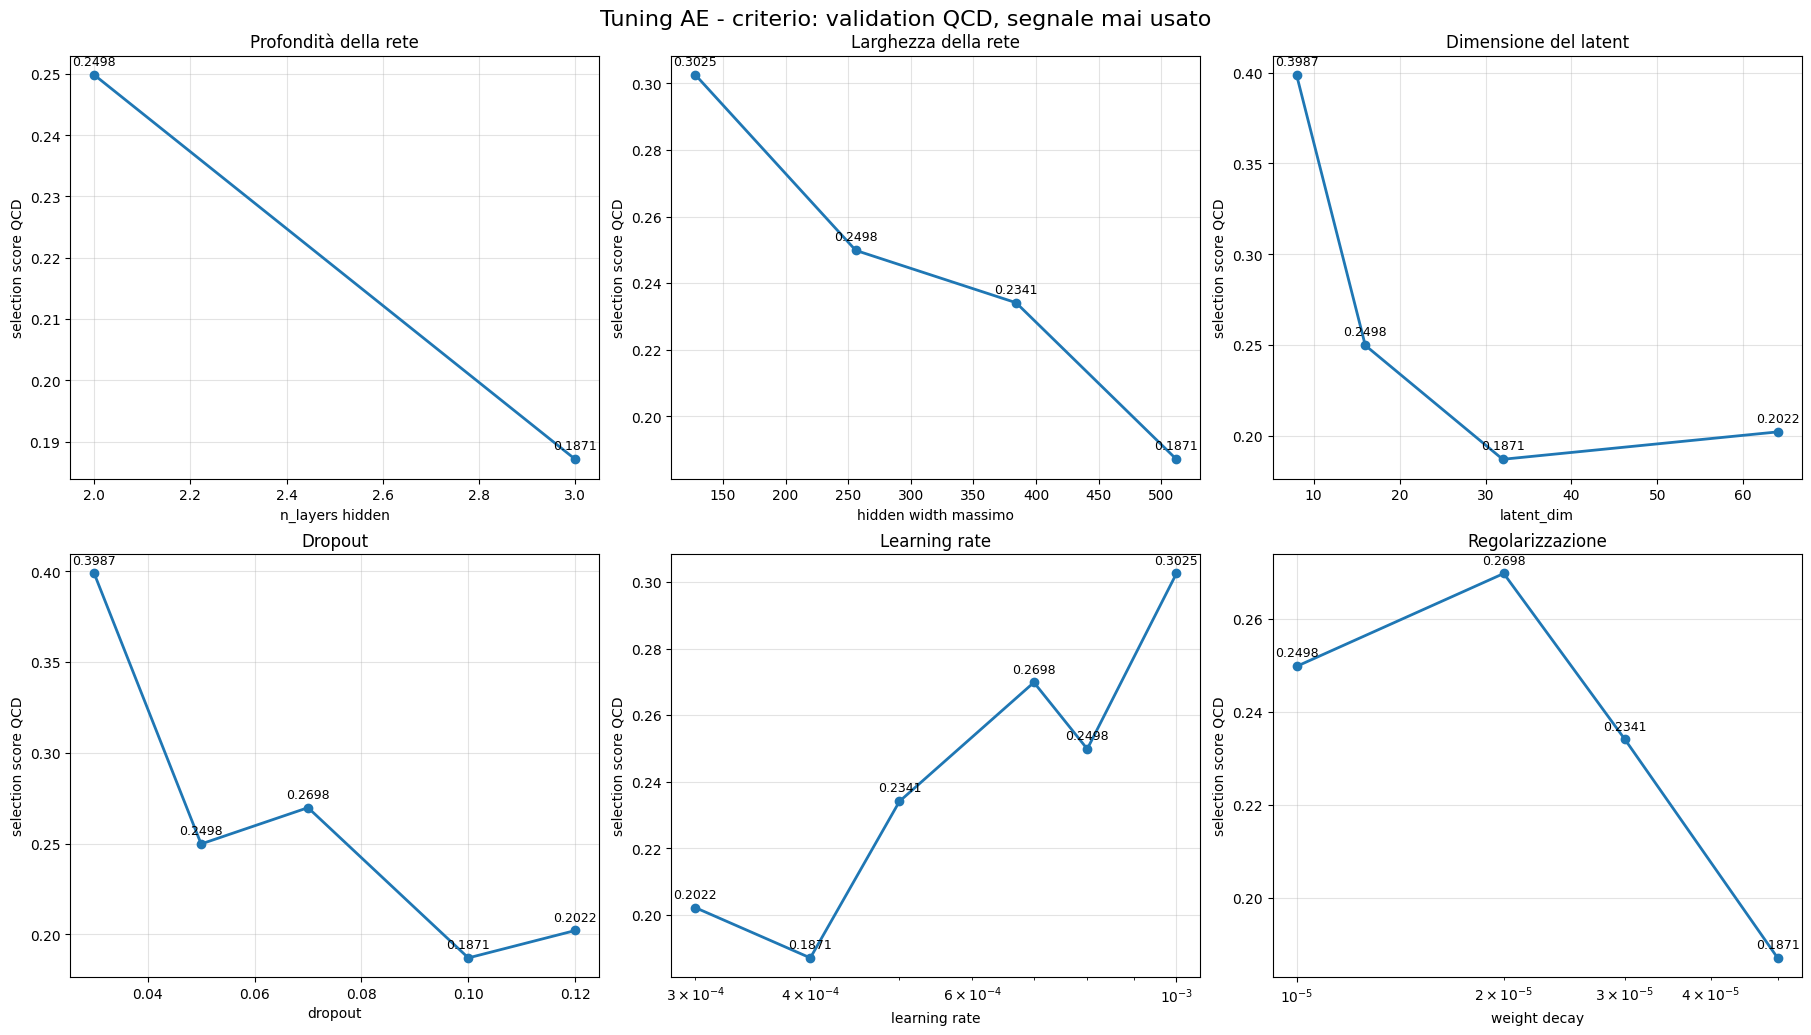

Salvato: ..\outputs\ae_vae\ae_hparam_elbow_plots.png


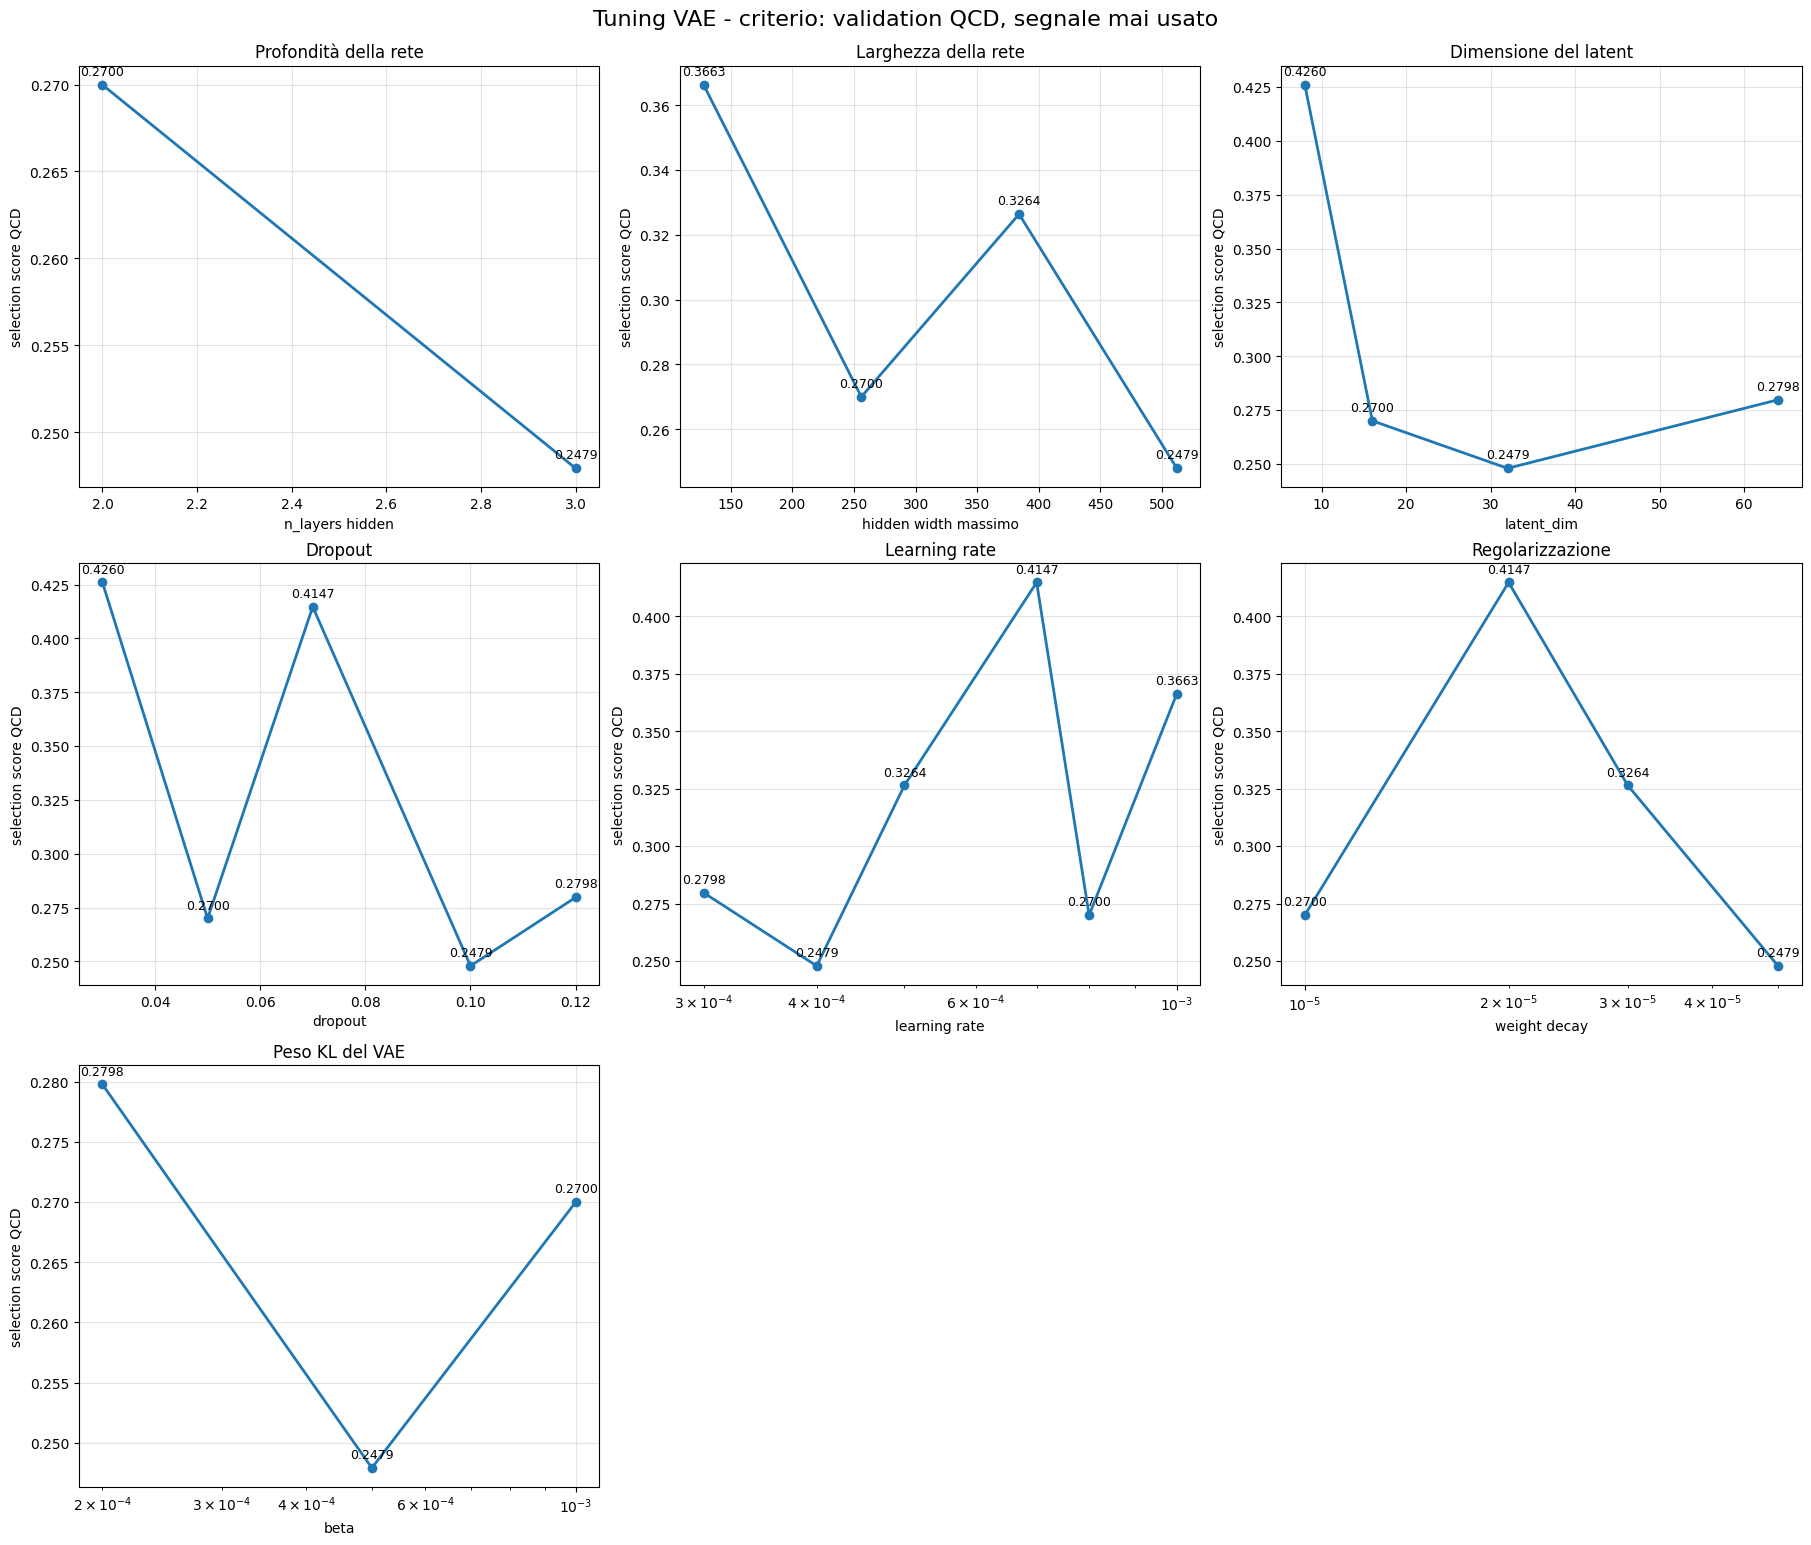

Salvato: ..\outputs\ae_vae\vae_hparam_elbow_plots.png


In [26]:
# ============================================================
# Plot tuning AE/VAE 
# ============================================================

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se tuning_results_df non è in memoria, lo carico dal CSV.
try:
    df = tuning_results_df.copy()
except NameError:
    df = pd.read_csv(OUTPUT_DIR / "ae_vae_hparam_tuning.csv")

# ------------------------------------------------------------
# Utility
# ------------------------------------------------------------

def parse_hidden_dims(x):
    if isinstance(x, list):
        return x

    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, list):
                return y
        except Exception:
            pass

    return [int(x)] if str(x).isdigit() else []


def add_architecture_columns(df):
    df = df.copy()

    df["hidden_dims_list"] = df["hidden_dims"].apply(parse_hidden_dims)

    # profondità = numero di layer hidden
    df["depth"] = df["hidden_dims_list"].apply(len)

    # larghezza = layer più largo
    df["width"] = df["hidden_dims_list"].apply(lambda x: max(x) if len(x) else np.nan)

    # architettura leggibile
    df["architecture"] = df["hidden_dims_list"].apply(
        lambda x: "-".join(map(str, x)) if len(x) else "unknown"
    )

    return df


df = add_architecture_columns(df)


Y_COL = "selection_score"
Y_LABEL = "selection score QCD"


def best_by_param(data, param):
    """
    Per ogni valore dell'iperparametro prendo la migliore configurazione,
    cioè quella con selection_score minimo.
    """
    out = (
        data
        .groupby(param, as_index=False)[Y_COL]
        .min()
        .sort_values(param)
        .reset_index(drop=True)
    )
    return out


def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
    ax.plot(x, y, marker="o", linewidth=2)

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.4f}",
            xy=(xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")


def plot_tuning_style_for_model(model_type):
    data = df[df["model_type"] == model_type].copy()

    if len(data) == 0:
        print(f"Nessun risultato per {model_type}")
        return

    # Parametri principali da mostrare.
    latent = best_by_param(data, "latent_dim")
    dropout = best_by_param(data, "dropout")
    depth = best_by_param(data, "depth")
    width = best_by_param(data, "width")
    lr = best_by_param(data, "lr")
    wd = best_by_param(data, "weight_decay")

    has_beta = (
    model_type.upper() == "VAE"
    and "beta" in data.columns
    and data["beta"].notna().any()
)

    if has_beta:
      beta = best_by_param(data, "beta")



    ncols = 3
    nrows = 2 if not has_beta else 3

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(18, 5 * nrows),
        constrained_layout=True,
    )

    axes = axes.flatten()

    fig.suptitle(
        f"Tuning {model_type} - criterio: validation QCD, segnale mai usato",
        fontsize=16,
        y=1.02,
    )

    plot_line_with_labels(
        axes[0],
        depth["depth"],
        depth[Y_COL],
        "n_layers hidden",
        "Profondità della rete",
    )

    plot_line_with_labels(
        axes[1],
        width["width"],
        width[Y_COL],
        "hidden width massimo",
        "Larghezza della rete",
    )

    plot_line_with_labels(
        axes[2],
        latent["latent_dim"],
        latent[Y_COL],
        "latent_dim",
        "Dimensione del latent",
    )

    plot_line_with_labels(
        axes[3],
        dropout["dropout"],
        dropout[Y_COL],
        "dropout",
        "Dropout",
    )

    plot_line_with_labels(
        axes[4],
        lr["lr"],
        lr[Y_COL],
        "learning rate",
        "Learning rate",
        logx=True,
    )

    plot_line_with_labels(
        axes[5],
        wd["weight_decay"],
        wd[Y_COL],
        "weight decay",
        "Regolarizzazione",
        logx=True,
    )

    if has_beta:
        plot_line_with_labels(
            axes[6],
            beta["beta"],
            beta[Y_COL],
            "beta",
            "Peso KL del VAE",
            logx=True,
        )

        # Nascondo subplot vuoti se ce ne sono.
        for ax in axes[7:]:
            ax.axis("off")

    # Salvataggio
    safe_name = model_type.lower().replace(" ", "_")
    out_path = OUTPUT_DIR / f"{safe_name}_hparam_elbow_plots.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Salvato:", out_path)



plot_tuning_style_for_model("AE")
plot_tuning_style_for_model("VAE")

## 7. Training utilities

In [27]:

class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-5):
        # patience indica per quante epoche consecutive possiamo tollerare
        # che la loss di validazione non migliori.
        # In questo caso, se per 15 epoche non vediamo miglioramenti reali,
        # interrompiamo il training.
        # min_delta definisce il miglioramento minimo richiesto.
        # Serve per evitare di considerare come "miglioramento" variazioni
        # numeriche molto piccole e poco significative.
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")  
        self.counter = 0
        self.best_state = None

    def step(self, value, model):

        #fa gli step dei training finchè non migliora
        if value < self.best - self.min_delta:
            self.best = value
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def eval_ae_loss(model, loader):
    #valuta il modello, NON aggiorna i pesi
    model.eval()
    losses = []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, _ = model(x)
            # Calcoliamo l'errore quadratico medio tra input e ricostruzione.
            loss = F.mse_loss(xhat, x, reduction="mean")
            losses.append(loss.item())
    return float(np.mean(losses))


def vae_loss_terms(xhat, x, mu, logvar, beta=BETA):
    #mse per il vae
    reco = F.mse_loss(xhat, x, reduction="mean")
    # Termine KL, cioè Kullback-Leibler divergence, la usiamo per lo spazio latente
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = reco + beta * kl
    return total, reco, kl


def eval_vae_loss(model, loader, beta=BETA):
    # La loss totale è la somma di due contributi:
    # 1. errore di ricostruzione
    # 2. regolarizzazione dello spazio latente tramite KL
    # beta controlla quanto peso dare al termine KL.
    
    model.eval()
    totals, recos, kls = [], [], []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, mu, logvar, _ = model(x, sample=False)
            total, reco, kl = vae_loss_terms(xhat, x, mu, logvar, beta)
            totals.append(total.item())
            recos.append(reco.item())
            kls.append(kl.item())
    return float(np.mean(totals)), float(np.mean(recos)), float(np.mean(kls))


## 8. Training Autoencoder

In [28]:
def train_autoencoder(model, train_loader, eval_loader, max_epochs=MAX_EPOCHS_AE):
    opt = torch.optim.AdamW(model.parameters(), lr=AE_LR, weight_decay=AE_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    early = EarlyStopping(patience=PATIENCE)
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for (x,) in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat, _ = model(x)
            loss = F.mse_loss(xhat, x, reduction="mean")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        eval_loss = eval_ae_loss(model, eval_loader)
        scheduler.step(eval_loss)
        history.append({"epoch": epoch, "train_loss": train_loss, "eval_loss": eval_loss})

        if epoch == 1 or epoch % 10 == 0:
            print(f"[AE] epoch {epoch:03d} | train={train_loss:.6f} | eval={eval_loss:.6f}")

        if early.step(eval_loss, model):
            print(f"[AE] early stopping at epoch {epoch}, best eval={early.best:.6f}")
            break

    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return pd.DataFrame(history)

hist_ae = train_autoencoder(ae, train_loader, eval_loader)

[AE] epoch 001 | train=0.478527 | eval=0.272916
[AE] epoch 010 | train=0.176281 | eval=0.105530
[AE] epoch 020 | train=0.150553 | eval=0.086559
[AE] epoch 030 | train=0.139155 | eval=0.075690
[AE] epoch 040 | train=0.132648 | eval=0.071192
[AE] epoch 050 | train=0.128834 | eval=0.068286
[AE] epoch 060 | train=0.125349 | eval=0.064590
[AE] epoch 070 | train=0.122723 | eval=0.062924
[AE] epoch 080 | train=0.120949 | eval=0.061180
[AE] epoch 090 | train=0.119605 | eval=0.060185
[AE] epoch 100 | train=0.118913 | eval=0.060570
[AE] epoch 110 | train=0.117700 | eval=0.059023
[AE] epoch 120 | train=0.115718 | eval=0.057284
[AE] epoch 130 | train=0.115331 | eval=0.057408
[AE] epoch 140 | train=0.113960 | eval=0.055999
[AE] epoch 150 | train=0.113985 | eval=0.055795
[AE] epoch 160 | train=0.113672 | eval=0.055927
[AE] epoch 170 | train=0.113397 | eval=0.055589
[AE] epoch 180 | train=0.113265 | eval=0.055706
[AE] epoch 190 | train=0.112492 | eval=0.055072
[AE] epoch 200 | train=0.112272 | eval=0

## 9. Training VAE

In [29]:
#ae su mse, vae su mse + kl 

def train_vae(model, train_loader, eval_loader, max_epochs=MAX_EPOCHS_VAE, beta=BETA):
    opt = torch.optim.AdamW(model.parameters(), lr=VAE_LR, weight_decay=VAE_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    early = EarlyStopping(patience=PATIENCE)
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        totals, recos, kls = [], [], []
        for (x,) in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat, mu, logvar, _ = model(x, sample=True)
            total, reco, kl = vae_loss_terms(xhat, x, mu, logvar, beta)
            total.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            totals.append(total.item())
            recos.append(reco.item())
            kls.append(kl.item())

        train_total = float(np.mean(totals))
        train_reco = float(np.mean(recos))
        train_kl = float(np.mean(kls))
        eval_total, eval_reco, eval_kl = eval_vae_loss(model, eval_loader, beta)
        scheduler.step(eval_total)

        history.append({
            "epoch": epoch,
            "train_total": train_total,
            "train_reco": train_reco,
            "train_kl": train_kl,
            "eval_total": eval_total,
            "eval_reco": eval_reco,
            "eval_kl": eval_kl,
        })

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[VAE] epoch {epoch:03d} | "
                f"train={train_total:.6f} | eval={eval_total:.6f} | "
                f"eval_reco={eval_reco:.6f} | eval_kl={eval_kl:.6f}"
            )

        if early.step(eval_total, model):
            print(f"[VAE] early stopping at epoch {epoch}, best eval={early.best:.6f}")
            break

    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return pd.DataFrame(history)

hist_vae = train_vae(vae, train_loader, eval_loader)

[VAE] epoch 001 | train=0.608079 | eval=0.393932 | eval_reco=0.393053 | eval_kl=1.756762
[VAE] epoch 010 | train=0.229349 | eval=0.162131 | eval_reco=0.160354 | eval_kl=3.554789
[VAE] epoch 020 | train=0.196177 | eval=0.132190 | eval_reco=0.130285 | eval_kl=3.808862
[VAE] epoch 030 | train=0.172567 | eval=0.110602 | eval_reco=0.108476 | eval_kl=4.253569
[VAE] epoch 040 | train=0.162832 | eval=0.104849 | eval_reco=0.102528 | eval_kl=4.641843
[VAE] epoch 050 | train=0.157397 | eval=0.101491 | eval_reco=0.099188 | eval_kl=4.606119
[VAE] epoch 060 | train=0.152523 | eval=0.095065 | eval_reco=0.092770 | eval_kl=4.590086
[VAE] epoch 070 | train=0.148430 | eval=0.091904 | eval_reco=0.089613 | eval_kl=4.581082
[VAE] epoch 080 | train=0.144421 | eval=0.088228 | eval_reco=0.085940 | eval_kl=4.574879
[VAE] epoch 090 | train=0.140201 | eval=0.083324 | eval_reco=0.081039 | eval_kl=4.569641
[VAE] epoch 100 | train=0.138001 | eval=0.081159 | eval_reco=0.078876 | eval_kl=4.567716
[VAE] epoch 110 | tra

## 10. Curve di training

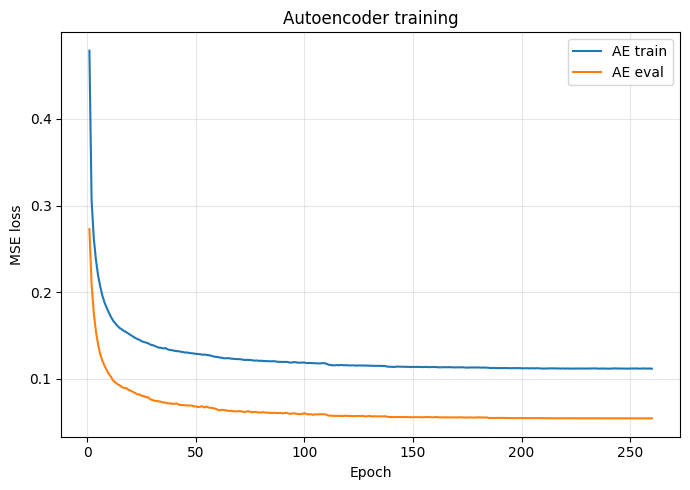

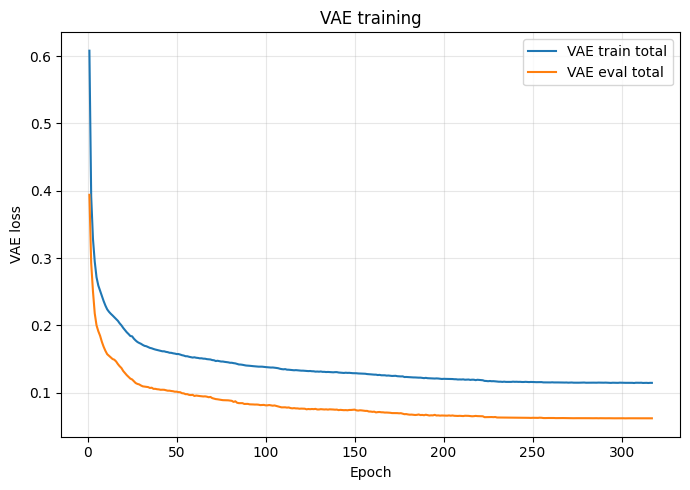

In [30]:

#grafici
plt.figure(figsize=(7, 5))
plt.plot(hist_ae["epoch"], hist_ae["train_loss"], label="AE train")
plt.plot(hist_ae["epoch"], hist_ae["eval_loss"], label="AE eval")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "ae_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist_vae["epoch"], hist_vae["train_total"], label="VAE train total")
plt.plot(hist_vae["epoch"], hist_vae["eval_total"], label="VAE eval total")
plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("VAE training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "vae_training_curve.png", dpi=200)
plt.show()


## 11. Calcolo anomaly score

Salviamo più score:

### AE
- `ae_mse`: MSE medio.
- `ae_whitened`: errore per feature pesato con la varianza dell'errore su QCD eval.

### VAE
- `vae_reco`: MSE medio.
- `vae_kl`: termine KL.
- `vae_total`: `reco + beta * KL`.
- `vae_official`: reconstruction whitened + distanza latente standardizzata.


In [31]:
def batch_predict_ae(model, X, batch_size=BATCH_SIZE):
    # Uso il modello in modalità evaluation, perché qui non sto facendo training
    # ma solo predizioni e ricostruzioni sui dati.
    model.eval()
    xs, xhats, zs = [], [], []

    # Scorro i dati a batch per non caricare tutto insieme in memoria.
    # shuffle=False serve a mantenere lo stesso ordine degli eventi.
    loader = make_loader(X, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)

            # L'autoencoder restituisce la ricostruzione e la rappresentazione latente.
            xhat, z = model(x)

            xs.append(x.cpu().numpy())
            xhats.append(xhat.cpu().numpy())
            zs.append(z.cpu().numpy())

    return np.concatenate(xs), np.concatenate(xhats), np.concatenate(zs)


def batch_predict_vae(model, X, batch_size=BATCH_SIZE):
    # Stessa idea dell'AE, ma nel VAE salvo anche media e log-varianza
    # della distribuzione latente.
    model.eval()
    xs, xhats, mus, logvars = [], [], [], []
    loader = make_loader(X, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)

            # sample=False rende la valutazione più stabile, evitando rumore casuale.
            xhat, mu, logvar, _ = model(x, sample=False)

            xs.append(x.cpu().numpy())
            xhats.append(xhat.cpu().numpy())
            mus.append(mu.cpu().numpy())
            logvars.append(logvar.cpu().numpy())

    return np.concatenate(xs), np.concatenate(xhats), np.concatenate(mus), np.concatenate(logvars)


def ae_scores_from_reco(X, Xhat, err_scale=None):
    # Errore quadratico di ricostruzione, calcolato feature per feature.
    err = (X - Xhat) ** 2

    # MSE medio per ogni evento/jet.
    mse = err.mean(axis=1)

    if err_scale is None:
        white = mse.copy()
    else:
        # Normalizzo l'errore usando una scala calcolata sul campione QCD di riferimento.
        # Così evito che feature con valori numerici più grandi pesino troppo nello score.
        white = (err / err_scale).mean(axis=1)

    return mse.astype(np.float32), white.astype(np.float32), err


def kl_from_mu_logvar(mu, logvar):
    # Termine KL del VAE: misura quanto la distribuzione latente si discosta
    # dalla normale standard usata come prior.
    kl_per_dim = -0.5 * (1 + logvar - mu ** 2 - np.exp(logvar))
    return kl_per_dim.mean(axis=1).astype(np.float32)


def zscore_with_eval(x, eval_x):
    # Standardizzo uno score rispetto alla distribuzione del campione QCD di evaluation.
    mu = np.mean(eval_x)
    sd = np.std(eval_x)
    if sd < 1e-8:
        sd = 1.0
    return (x - mu) / sd

# AE predictions
# Applico l'autoencoder ai vari campioni: train, evaluation QCD, background e segnale.
Xtr_ae, Xh_tr_ae, Ztr_ae = batch_predict_ae(ae, X_train)
Xev_ae, Xh_ev_ae, Zev_ae = batch_predict_ae(ae, X_eval)
Xbg_ae, Xh_bg_ae, Zbg_ae = batch_predict_ae(ae, X_bg)
Xsg_ae, Xh_sg_ae, Zsg_ae = batch_predict_ae(ae, X_sig)

# Errore medio per feature su eval QCD: usato per whitening dello score AE
_, _, err_eval_ae = ae_scores_from_reco(Xev_ae, Xh_ev_ae)
ae_err_scale = err_eval_ae.mean(axis=0) + 1e-8

# Calcolo gli score AE sui diversi campioni.
ae_train_mse, ae_train_white, ae_err_train = ae_scores_from_reco(Xtr_ae, Xh_tr_ae, ae_err_scale)
ae_eval_mse, ae_eval_white, ae_err_eval = ae_scores_from_reco(Xev_ae, Xh_ev_ae, ae_err_scale)
ae_bg_mse, ae_bg_white, ae_err_bg = ae_scores_from_reco(Xbg_ae, Xh_bg_ae, ae_err_scale)
ae_sig_mse, ae_sig_white, ae_err_sig = ae_scores_from_reco(Xsg_ae, Xh_sg_ae, ae_err_scale)

# VAE predictions
# Applico il VAE e salvo ricostruzioni, medie e log-varianze latenti.
Xtr_v, Xh_tr_v, Mu_tr, Lv_tr = batch_predict_vae(vae, X_train)
Xev_v, Xh_ev_v, Mu_ev, Lv_ev = batch_predict_vae(vae, X_eval)
Xbg_v, Xh_bg_v, Mu_bg, Lv_bg = batch_predict_vae(vae, X_bg)
Xsg_v, Xh_sg_v, Mu_sg, Lv_sg = batch_predict_vae(vae, X_sig)

# Anche per il VAE uso l'errore medio su eval QCD come scala di normalizzazione.
_, _, err_eval_vae = ae_scores_from_reco(Xev_v, Xh_ev_v)
vae_err_scale = err_eval_vae.mean(axis=0) + 1e-8

vae_train_reco, vae_train_white, vae_err_train = ae_scores_from_reco(Xtr_v, Xh_tr_v, vae_err_scale)
vae_eval_reco, vae_eval_white, vae_err_eval = ae_scores_from_reco(Xev_v, Xh_ev_v, vae_err_scale)
vae_bg_reco, vae_bg_white, vae_err_bg = ae_scores_from_reco(Xbg_v, Xh_bg_v, vae_err_scale)
vae_sig_reco, vae_sig_white, vae_err_sig = ae_scores_from_reco(Xsg_v, Xh_sg_v, vae_err_scale)

# Calcolo il termine KL per ogni campione.
vae_train_kl = kl_from_mu_logvar(Mu_tr, Lv_tr)
vae_eval_kl = kl_from_mu_logvar(Mu_ev, Lv_ev)
vae_bg_kl = kl_from_mu_logvar(Mu_bg, Lv_bg)
vae_sig_kl = kl_from_mu_logvar(Mu_sg, Lv_sg)

# Loss totale del VAE: ricostruzione + beta * KL.
vae_train_total = vae_train_reco + BETA * vae_train_kl
vae_eval_total = vae_eval_reco + BETA * vae_eval_kl
vae_bg_total = vae_bg_reco + BETA * vae_bg_kl
vae_sig_total = vae_sig_reco + BETA * vae_sig_kl

# Latent anomaly: distanza diagonale tipo Mahalanobis rispetto a QCD eval
# Calcolo media e deviazione standard dello spazio latente sul campione QCD di riferimento.
mu0 = Mu_ev.mean(axis=0)
s0 = Mu_ev.std(axis=0)
s0 = np.where(s0 < 1e-6, 1.0, s0)

def latent_diag_maha(Mu):
    # Score di anomalia nello spazio latente:
    # più un evento è lontano dal QCD tipico, più questo valore aumenta.
    return (((Mu - mu0) / s0) ** 2).mean(axis=1).astype(np.float32)

lat_train = latent_diag_maha(Mu_tr)
lat_eval = latent_diag_maha(Mu_ev)
lat_bg = latent_diag_maha(Mu_bg)
lat_sig = latent_diag_maha(Mu_sg)

# Score official VAE: somma di componenti standardizzate rispetto a eval QCD
# Combino errore di ricostruzione e distanza latente dopo averli messi sulla stessa scala.
vae_train_official = zscore_with_eval(vae_train_white, vae_eval_white) + zscore_with_eval(lat_train, lat_eval)
vae_eval_official = zscore_with_eval(vae_eval_white, vae_eval_white) + zscore_with_eval(lat_eval, lat_eval)
vae_bg_official = zscore_with_eval(vae_bg_white, vae_eval_white) + zscore_with_eval(lat_bg, lat_eval)
vae_sig_official = zscore_with_eval(vae_sig_white, vae_eval_white) + zscore_with_eval(lat_sig, lat_eval)

print("Score calcolati.")
print("AE white bg/sig mean:", ae_bg_white.mean(), ae_sig_white.mean())
print("VAE official bg/sig mean:", vae_bg_official.mean(), vae_sig_official.mean())

Score calcolati.
AE white bg/sig mean: 0.9896058 8.397645e+07
VAE official bg/sig mean: -3.2958983e-08 4.046543e+07


## 12. Metriche: ROC/AUC, efficienza a mistag fissato, background check

In [32]:

def orient_scores(bg_scores, sig_scores):
    # Rende lo score orientato: valore alto = piu signal-like.
    y = np.concatenate([np.zeros_like(bg_scores), np.ones_like(sig_scores)])
    s = np.concatenate([bg_scores, sig_scores])
    auc = roc_auc_score(y, s)
    #inverte lo score se è al contrario (ci interessa da 0.5 a 1)
    if auc < 0.5:
        return -bg_scores, -sig_scores, 1.0 - auc, True
    return bg_scores, sig_scores, auc, False


def eff_at_mistag(bg_scores, sig_scores, mistag):
    threshold = np.quantile(bg_scores, 1.0 - mistag)
    eff = np.mean(sig_scores >= threshold)
    return float(eff), float(threshold)


def bg_consistency_auc(train_scores, eval_scores):
    n = min(len(train_scores), len(eval_scores))
    rng = np.random.default_rng(SEED)
    tr = train_scores[rng.choice(len(train_scores), size=n, replace=False)]
    ev = eval_scores[rng.choice(len(eval_scores), size=n, replace=False)]
    y = np.concatenate([np.zeros(n), np.ones(n)])
    s = np.concatenate([tr, ev])
    auc = roc_auc_score(y, s)
    return max(float(auc), float(1.0 - auc))


def evaluate_score(name, train_scores, eval_scores, bg_scores, sig_scores):
    bg_o, sig_o, auc, flipped = orient_scores(bg_scores, sig_scores)
    train_o = -train_scores if flipped else train_scores
    eval_o = -eval_scores if flipped else eval_scores

    fpr, tpr, _ = roc_curve(
        np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)]),
        np.concatenate([bg_o, sig_o]),
    )

    row = {
        "model": name,
        "auc": float(auc),
        "flipped_score": bool(flipped),
        "train_vs_eval_bg_auc": bg_consistency_auc(train_o, eval_o),
    }
    for m in [0.30, 0.10, 0.05, 0.01, 0.001]:
        eff, thr = eff_at_mistag(bg_o, sig_o, m)
        row[f"eff_at_{m:g}_mistag"] = eff
        row[f"threshold_at_{m:g}_mistag"] = thr

    return row, fpr, tpr, bg_o, sig_o, train_o, eval_o

# Dizionario con tutti gli score da confrontare.
SCORES = {
    "AE MSE": (ae_train_mse, ae_eval_mse, ae_bg_mse, ae_sig_mse),
    "AE whitened": (ae_train_white, ae_eval_white, ae_bg_white, ae_sig_white),
    "VAE reco": (vae_train_reco, vae_eval_reco, vae_bg_reco, vae_sig_reco),
    "VAE KL": (vae_train_kl, vae_eval_kl, vae_bg_kl, vae_sig_kl),
    "VAE total": (vae_train_total, vae_eval_total, vae_bg_total, vae_sig_total),
    "VAE official": (vae_train_official, vae_eval_official, vae_bg_official, vae_sig_official),
}

results = []
curves = {}
oriented_scores = {}

for name, vals in SCORES.items():
    row, fpr, tpr, bg_o, sig_o, train_o, eval_o = evaluate_score(name, *vals)
    results.append(row)
    curves[name] = (fpr, tpr)
    oriented_scores[name] = {
        "train": train_o,
        "eval": eval_o,
        "bg": bg_o,
        "sig": sig_o,
    }

df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
display(df_results)


,model,auc,flipped_score,train_vs_eval_bg_auc,eff_at_0.3_mistag,threshold_at_0.3_mistag,eff_at_0.1_mistag,threshold_at_0.1_mistag,eff_at_0.05_mistag,threshold_at_0.05_mistag,eff_at_0.01_mistag,threshold_at_0.01_mistag,eff_at_0.001_mistag,threshold_at_0.001_mistag
5,VAE official,0.882506,False,0.500450,0.898912,0.054421,0.652923,1.074681,0.427089,2.052682,0.125440,5.158512,0.034777,11.594033
1,AE whitened,0.867221,False,0.507638,0.861359,1.017281,0.631153,1.444451,0.456928,1.804292,0.184230,3.125189,0.051173,12.472263
3,VAE KL,0.859652,False,0.502850,0.866701,4.561290,0.585789,4.599439,0.373979,4.633414,0.035907,4.760839,0.008279,4.891743
4,VAE total,0.852372,False,0.509064,0.830439,0.067293,0.599409,0.090320,0.463722,0.105784,0.220605,0.153412,0.056273,0.373135
2,VAE reco,0.852290,False,0.509071,0.830342,0.065008,0.599216,0.088034,0.463561,0.103494,0.220605,0.151108,0.056273,0.370731
0,AE MSE,0.848790,False,0.509005,0.826292,0.059461,0.590743,0.080057,0.448940,0.094298,0.208760,0.137793,0.061017,0.336163


## 13. Plot finali AE/VAE

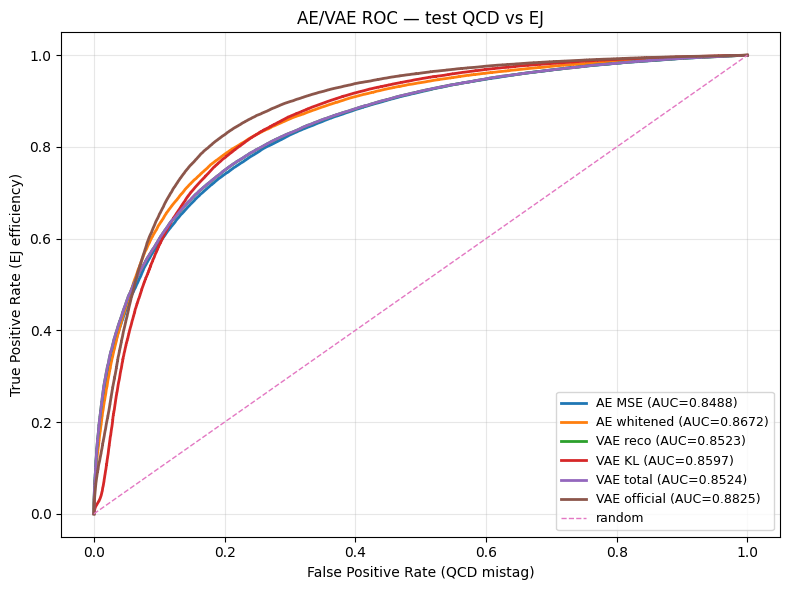

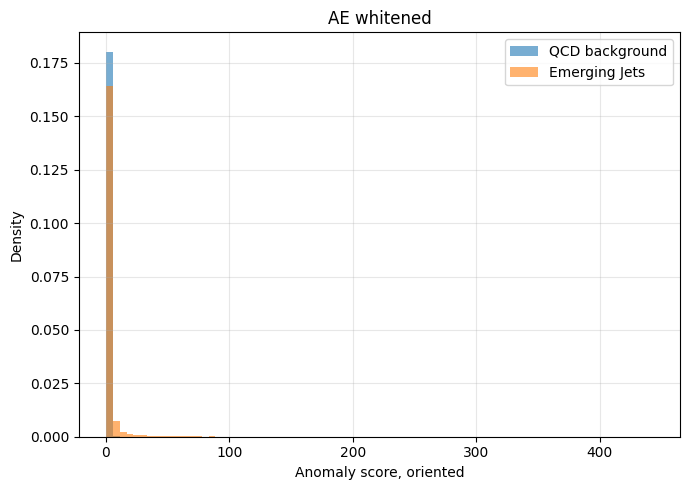

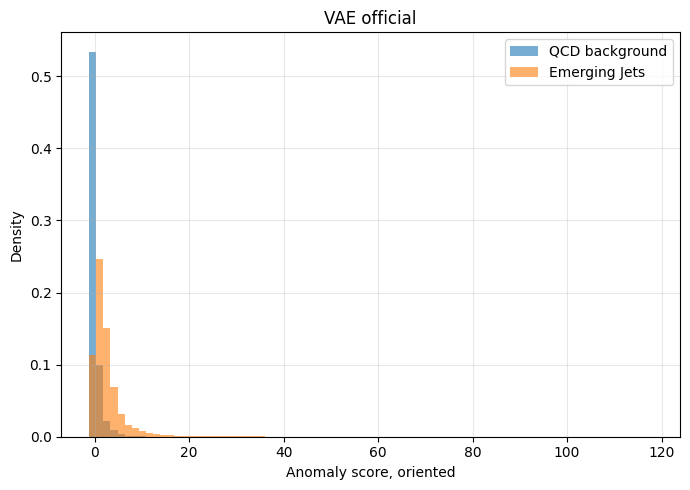

In [33]:

# ROC curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in curves.items():
    auc = df_results.loc[df_results["model"] == name, "auc"].values[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="random")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("AE/VAE ROC — test QCD vs EJ")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "ae_vae_roc.png", dpi=250)
plt.show()

# Score distributions per score migliore AE e VAE official
for name in ["AE whitened", "VAE official"]:
    bg = oriented_scores[name]["bg"]
    sig = oriented_scores[name]["sig"]
    lo = np.quantile(np.concatenate([bg, sig]), 0.001)
    hi = np.quantile(np.concatenate([bg, sig]), 0.999)
    plt.figure(figsize=(7, 5))
    plt.hist(bg, bins=80, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
    plt.hist(sig, bins=80, range=(lo, hi), density=True, alpha=0.6, label="Emerging Jets")
    plt.xlabel("Anomaly score, oriented")
    plt.ylabel("Density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    safe = name.lower().replace(" ", "_")
    plt.savefig(OUTPUT_DIR / "plots" / f"score_distribution_{safe}.png", dpi=250)
    plt.show()


## 14. Per-feature reconstruction error

Questo plot aiuta a capire quali feature aggregate guidano l'anomaly score.

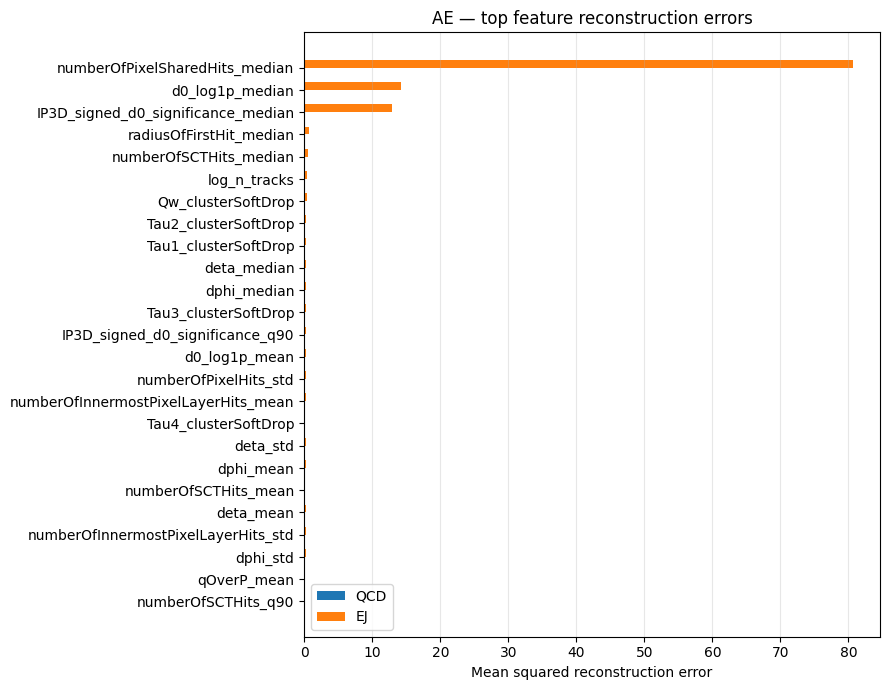

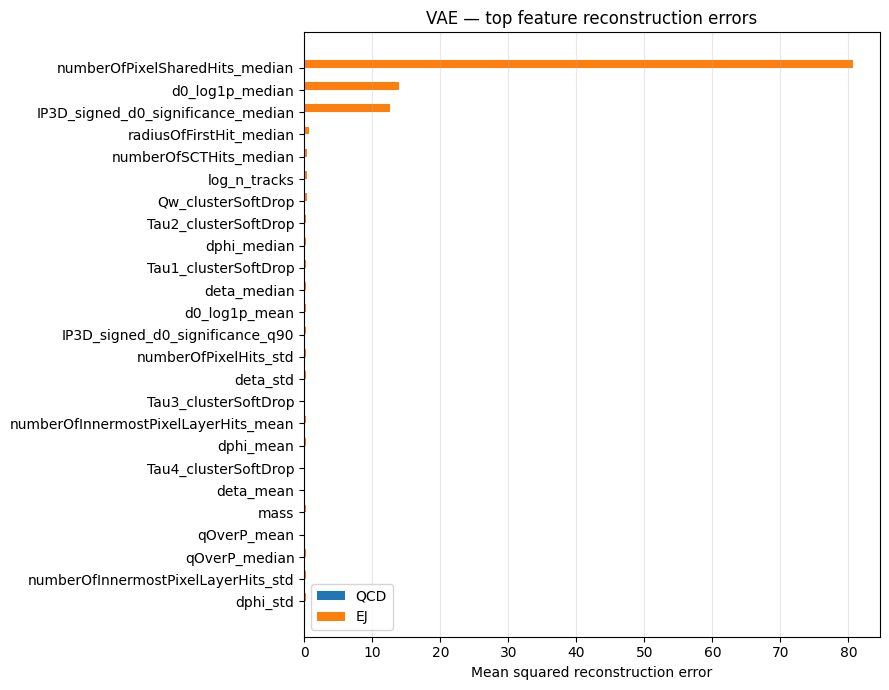

In [34]:

def plot_top_feature_errors(err_bg, err_sig, title, filename, top_k=25):
    diff = err_sig.mean(axis=0) - err_bg.mean(axis=0)
    order = np.argsort(diff)[-top_k:]
    labels = [feature_names[i] for i in order]

    plt.figure(figsize=(9, max(5, 0.28 * top_k)))
    y = np.arange(top_k)
    plt.barh(y - 0.18, err_bg.mean(axis=0)[order], height=0.35, label="QCD")
    plt.barh(y + 0.18, err_sig.mean(axis=0)[order], height=0.35, label="EJ")
    plt.yticks(y, labels)
    plt.xlabel("Mean squared reconstruction error")
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / filename, dpi=250)
    plt.show()

plot_top_feature_errors(ae_err_bg, ae_err_sig, "AE — top feature reconstruction errors", "ae_top_feature_errors.png")
plot_top_feature_errors(vae_err_bg, vae_err_sig, "VAE — top feature reconstruction errors", "vae_top_feature_errors.png")


in entrambi i casi d0 e il suo errore sono la feature più importante

## 15. Salvataggio output

Questi output saranno poi caricati dal notebook Task 3 finale.

In [35]:
# Salva modelli
model_config = {
    "input_dim": int(input_dim),
    "hidden_dims": HIDDEN_DIMS,
    "latent_dim": LATENT_DIM,
    "dropout": DROPOUT,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "ae_hidden_dims": AE_HIDDEN_DIMS,
    "ae_latent_dim": AE_LATENT_DIM,
    "ae_dropout": AE_DROPOUT,
    "ae_lr": AE_LR,
    "ae_weight_decay": AE_WEIGHT_DECAY,
    "vae_hidden_dims": VAE_HIDDEN_DIMS,
    "vae_latent_dim": VAE_LATENT_DIM,
    "vae_dropout": VAE_DROPOUT,
    "vae_lr": VAE_LR,
    "vae_weight_decay": VAE_WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "beta": BETA,
    "logvar_clamp": LOGVAR_CLAMP,
    "seed": SEED,
    "processed_dir": str(PROCESSED_DIR),
    "bg_test_name": bg_test_name,
    "scaler_info": SCALER_INFO,
}

torch.save({"state_dict": ae.state_dict(), "config": model_config}, OUTPUT_DIR / "ae_model.pt")
torch.save({"state_dict": vae.state_dict(), "config": model_config}, OUTPUT_DIR / "vae_model.pt")

# Salva risultati tabellari
df_results.to_csv(OUTPUT_DIR / "ae_vae_results.csv", index=False)
hist_ae.to_csv(OUTPUT_DIR / "ae_training_history.csv", index=False)
hist_vae.to_csv(OUTPUT_DIR / "vae_training_history.csv", index=False)

with open(OUTPUT_DIR / "ae_vae_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

with open(OUTPUT_DIR / "aggregate_feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Salva tutti gli score, compresi quelli orientati.
np.savez_compressed(
    OUTPUT_DIR / "ae_vae_scores.npz",
    # raw AE 
    ae_scores_train_mse=ae_train_mse,
    ae_scores_eval_mse=ae_eval_mse,
    ae_scores_bg_mse=ae_bg_mse,
    ae_scores_sig_mse=ae_sig_mse,
    ae_scores_train_whitened=ae_train_white,
    ae_scores_eval_whitened=ae_eval_white,
    ae_scores_bg_whitened=ae_bg_white,
    ae_scores_sig_whitened=ae_sig_white,
    # raw VAE
    vae_scores_train_reco=vae_train_reco,
    vae_scores_eval_reco=vae_eval_reco,
    vae_scores_bg_reco=vae_bg_reco,
    vae_scores_sig_reco=vae_sig_reco,
    vae_scores_train_kl=vae_train_kl,
    vae_scores_eval_kl=vae_eval_kl,
    vae_scores_bg_kl=vae_bg_kl,
    vae_scores_sig_kl=vae_sig_kl,
    vae_scores_train_total=vae_train_total,
    vae_scores_eval_total=vae_eval_total,
    vae_scores_bg_total=vae_bg_total,
    vae_scores_sig_total=vae_sig_total,
    vae_scores_train_official=vae_train_official,
    vae_scores_eval_official=vae_eval_official,
    vae_scores_bg_official=vae_bg_official,
    vae_scores_sig_official=vae_sig_official,
    # oriented scores for easy Task 3 loading
    ae_oriented_train=oriented_scores["AE whitened"]["train"],
    ae_oriented_eval=oriented_scores["AE whitened"]["eval"],
    ae_oriented_bg=oriented_scores["AE whitened"]["bg"],
    ae_oriented_sig=oriented_scores["AE whitened"]["sig"],
    vae_oriented_train=oriented_scores["VAE official"]["train"],
    vae_oriented_eval=oriented_scores["VAE official"]["eval"],
    vae_oriented_bg=oriented_scores["VAE official"]["bg"],
    vae_oriented_sig=oriented_scores["VAE official"]["sig"],
    # embeddings useful for diagnostics
    ae_Z_train=Ztr_ae,
    ae_Z_eval=Zev_ae,
    ae_Z_bg=Zbg_ae,
    ae_Z_sig=Zsg_ae,
    vae_mu_train=Mu_tr,
    vae_mu_eval=Mu_ev,
    vae_mu_bg=Mu_bg,
    vae_mu_sig=Mu_sg,
    feature_names=np.array(feature_names, dtype=object),
)

print("Salvato in:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)
print("Plots:")
for p in sorted((OUTPUT_DIR / "plots").glob("*.png")):
    print(" - plots/" + p.name)

Salvato in: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\ae_vae
 - ae_hparam_elbow_plots.png
 - ae_model.pt
 - ae_training_history.csv
 - ae_vae_config.json
 - ae_vae_hparam_tuning.csv
 - ae_vae_results.csv
 - ae_vae_scores.npz
 - aggregate_feature_names.json
 - hparam_architecture_vs_score.png
 - hparam_dropout_vs_score.png
 - hparam_latent_dim_vs_score.png
 - hparam_tuning_ranking.png
 - vae_hparam_elbow_plots.png
 - vae_model.pt
 - vae_training_history.csv
Plots:
 - plots/ae_top_feature_errors.png
 - plots/ae_training_curve.png
 - plots/ae_vae_roc.png
 - plots/score_distribution_ae_whitened.png
 - plots/score_distribution_vae_official.png
 - plots/vae_top_feature_errors.png
 - plots/vae_training_curve.png


## 16. Sintesi rapida per il report

In [36]:

#stampa la tabella con i risultati finali
print("Migliori score AE/VAE:")
display(df_results[[
    "model",
    "auc",
    "eff_at_0.1_mistag",
    "eff_at_0.01_mistag",
    "train_vs_eval_bg_auc",
]])

best = df_results.iloc[0]
print(
    f"Best AE/VAE score: {best['model']} | "
    f"AUC={best['auc']:.4f} | "
    f"Eff@10% mistag={best['eff_at_0.1_mistag']:.4f} | "
    f"Eff@1% mistag={best['eff_at_0.01_mistag']:.4f} | "
    f"train-vs-eval BG AUC={best['train_vs_eval_bg_auc']:.4f}"
)


Migliori score AE/VAE:


,model,auc,eff_at_0.1_mistag,eff_at_0.01_mistag,train_vs_eval_bg_auc
5,VAE official,0.882506,0.652923,0.125440,0.500450
1,AE whitened,0.867221,0.631153,0.184230,0.507638
3,VAE KL,0.859652,0.585789,0.035907,0.502850
4,VAE total,0.852372,0.599409,0.220605,0.509064
2,VAE reco,0.852290,0.599216,0.220605,0.509071
0,AE MSE,0.848790,0.590743,0.208760,0.509005


Best AE/VAE score: VAE official | AUC=0.8825 | Eff@10% mistag=0.6529 | Eff@1% mistag=0.1254 | train-vs-eval BG AUC=0.5005
